C:\Users\2021n\AppData\Local\Temp\ipykernel_20140\1183905510.py:10: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds1, ds2])
C:\Users\2021n\AppData\Local\Temp\ipykernel_20140\1183905510.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds1, ds2])
C:\Users\2021n\AppData\Local\Temp\ipykernel_20140\118390

Using grid point:
Lat: 32.75
Lon: 79.0


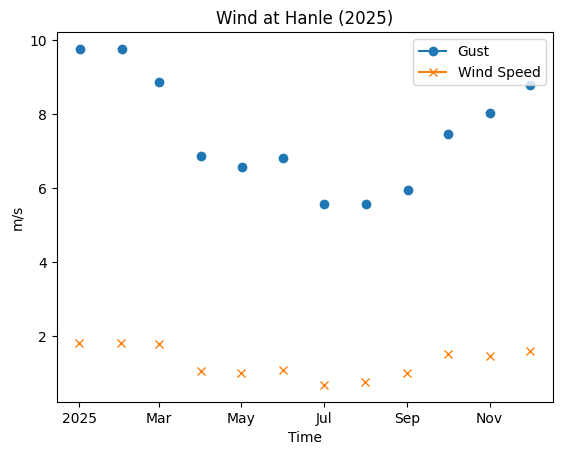

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# opening files
ds1 = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\5093875aeb516a2678d750247a04cf31\data.nc")     # gust (i10fg)
ds2 = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\5093875aeb516a2678d750247a04cf31\data1.nc")   # u10, v10 (or whatever your second file is)

# merging the two datasets
ds = xr.merge([ds1, ds2])

# assigning hanle to a certian gridpoint
hanle = ds.sel(
    latitude=32.78,
    longitude=78.96,
    method="nearest"
)

# print grid point
print("Using grid point:")
print("Lat:", float(hanle.latitude.values))
print("Lon:", float(hanle.longitude.values))

# extract variables
gust = hanle["i10fg"]
# compute the wind speed
if "u10" in hanle and "v10" in hanle:
    u = hanle["u10"]
    v = hanle["v10"]
    wind_speed = np.sqrt(u**2 + v**2)
else:
    wind_speed = None

#plot 
plt.figure()

gust.plot(marker='o', label="Gust")

if wind_speed is not None:
    wind_speed.plot(marker='x', label="Wind Speed")

plt.title("Wind at Hanle (2025)")
plt.xlabel("Time")
plt.ylabel("m/s")
plt.legend()

plt.show()

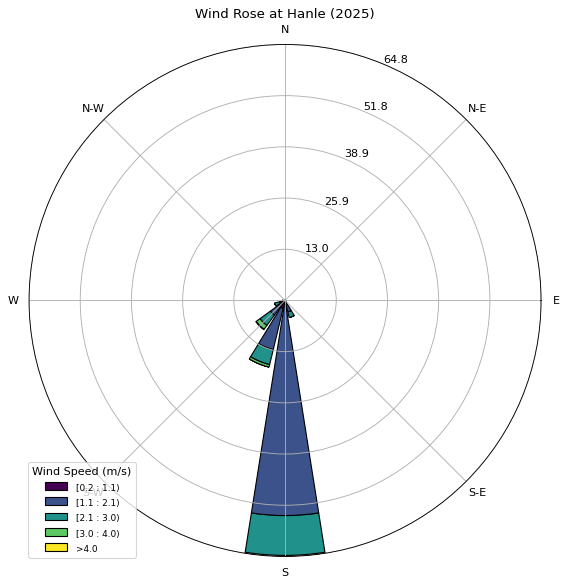

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes


ds1 = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\5093875aeb516a2678d750247a04cf31\data.nc")     # gust (i10fg)
# Select Hanle location
hanle = ds.sel(
    latitude=32.78,
    longitude=78.96,
    method="nearest"
)

u = hanle["u10"]
v = hanle["v10"]


# Wind speed
speed = np.sqrt(u**2 + v**2)

# Wind direction
direction = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# Flatten data
speed_vals = speed.values.flatten()
dir_vals = direction.values.flatten()

# Remove NaNs
mask = ~np.isnan(speed_vals)
speed_vals = speed_vals[mask]
dir_vals = dir_vals[mask]

# Define bins
binarray = np.linspace(np.min(speed_vals), np.max(speed_vals), 5)

# Create wind rose
ax = WindroseAxes.from_ax()
ax.bar(
    dir_vals,
    speed_vals,
    bins=binarray,
    normed=True,   
    edgecolor='black'
)

ax.set_title("Wind Rose at Hanle (2025)")
ax.set_legend(title="Wind Speed (m/s)")

plt.show()

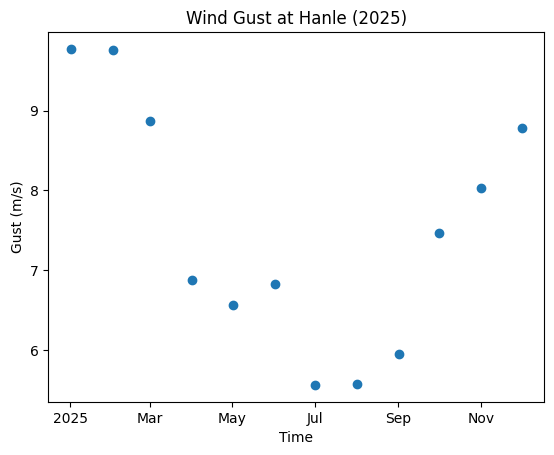

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

# gust file
ds1 = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\5093875aeb516a2678d750247a04cf31\data.nc")     # gust (i10fg)
#Hanle location
hanle = ds.sel(
    latitude=32.78,
    longitude=78.96,
    method="nearest"
)

# Extract gust
gust = hanle["i10fg"]

# Plot
plt.figure()
gust.plot(marker='o')

plt.title("Wind Gust at Hanle (2025)")
plt.xlabel("Time")
plt.ylabel("Gust (m/s)")

plt.show()

Data points: 12


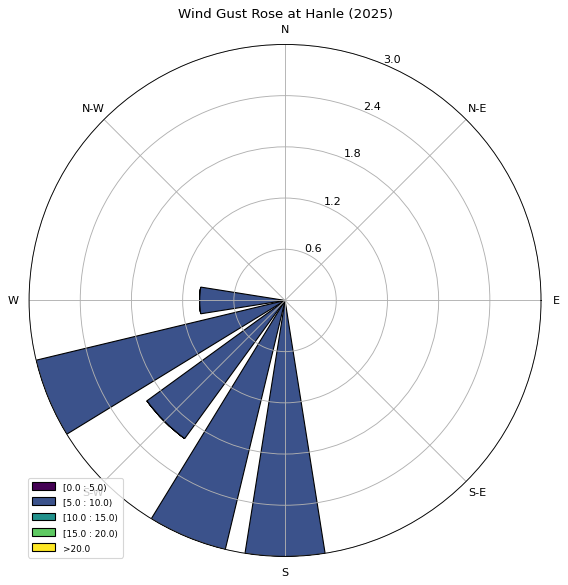

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# datasets
ds_gust = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\5093875aeb516a2678d750247a04cf31\data.nc")        # i10fg
ds_wind = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\5093875aeb516a2678d750247a04cf31\data1.nc")    # u10, v10


# location
gust = ds_gust.sel(latitude=32.78, longitude=78.96, method="nearest")["i10fg"]
u = ds_wind.sel(latitude=32.78, longitude=78.96, method="nearest")["u10"]
v = ds_wind.sel(latitude=32.78, longitude=78.96, method="nearest")["v10"]

# convert
gust_vals = gust.values.flatten()
u_vals = u.values.flatten()
v_vals = v.values.flatten()

# troubleshooting 
min_len = min(len(gust_vals), len(u_vals), len(v_vals))

gust_vals = gust_vals[:min_len]
u_vals = u_vals[:min_len]
v_vals = v_vals[:min_len]

# compute direction
dir_vals = (np.degrees(np.arctan2(u_vals, v_vals)) + 180) % 360

# remove the NaNs
mask = ~np.isnan(gust_vals)
gust_vals = gust_vals[mask]
dir_vals = dir_vals[mask]

print("Data points:", len(gust_vals))

#Plot
ax = WindroseAxes.from_ax()

ax.bar(dir_vals, gust_vals,
       bins=[0, 5, 10, 15, 20],
       edgecolor='black')

ax.set_title("Wind Gust Rose at Hanle (2025)")
ax.set_legend()

plt.show()

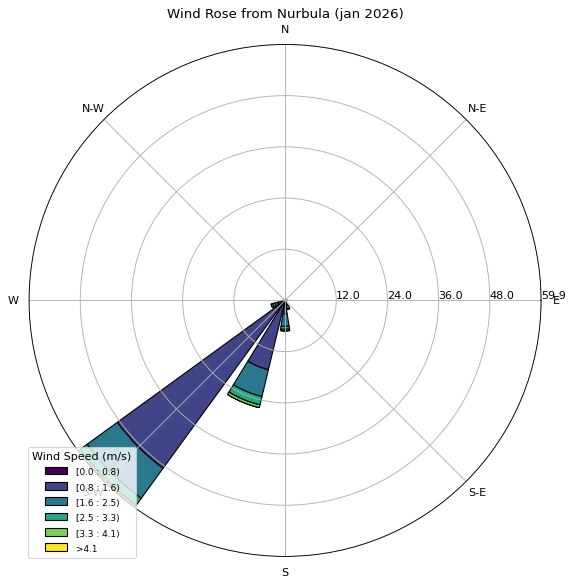

4.1112075


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

#data
ds = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\jan.nc")

#varible names
if "u10" in ds.variables:
    u = ds["u10"]
    v = ds["v10"]
elif "10m_u_component_of_wind" in ds.variables:
    u = ds["10m_u_component_of_wind"]
    v = ds["10m_v_component_of_wind"]
else:
    raise KeyError("Could not find wind variables. Run print(ds) and check names.")

# lat lons
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Could not find latitude/longitude names.")

#location for nurbula
u = u.sel({lat_name: 32.804, lon_name: 78.396}, method="nearest")
v = v.sel({lat_name: 32.804, lon_name: 78.396}, method="nearest")

# compute wind
speed = np.sqrt(u**2 + v**2)
direction = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# flaten (wasnt working without)
speed_vals = speed.values.flatten()
dir_vals = direction.values.flatten()

mask = ~np.isnan(speed_vals)
speed_vals = speed_vals[mask]
dir_vals = dir_vals[mask]

# bins 
binarray = np.linspace(0, np.max(speed_vals), 6)

# wind rose (as percent)
ax = WindroseAxes.from_ax()

ax.bar(
    dir_vals,
    speed_vals,
    bins=binarray,
    normed=True,  
    edgecolor='black'
)

ax.set_title("Wind Rose from Nurbula (jan 2026)")
ax.set_legend(title="Wind Speed (m/s)")
ax.set_rlabel_position(0)

plt.show()

print(np.max(speed_vals))

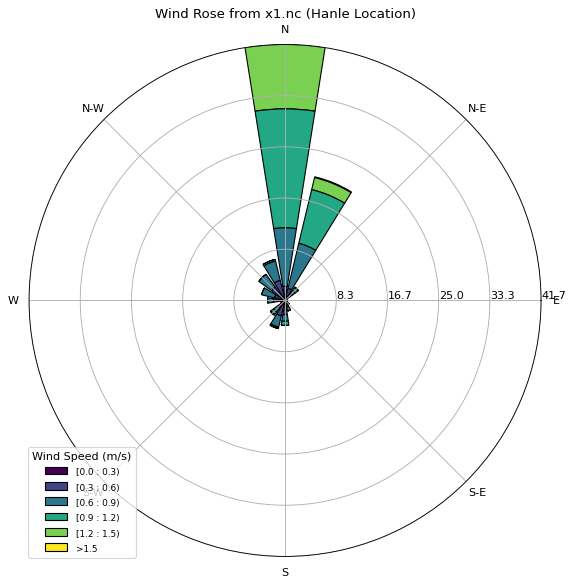

1.5437806


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

#data
ds = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\x1.nc")

# varible names
if "u10" in ds.variables:
    u = ds["u10"]
    v = ds["v10"]
elif "10m_u_component_of_wind" in ds.variables:
    u = ds["10m_u_component_of_wind"]
    v = ds["10m_v_component_of_wind"]
else:
    raise KeyError("Could not find wind variables. Run print(ds) and check names.")

# lat lon names
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Could not find latitude/longitude names.")

# location
u = u.sel({lat_name: 32, lon_name: 78}, method="nearest")
v = v.sel({lat_name: 32, lon_name: 78}, method="nearest")

#wind
speed = np.sqrt(u**2 + v**2)
direction = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# data clean
speed_vals = speed.values.flatten()
dir_vals = direction.values.flatten()

mask = ~np.isnan(speed_vals)
speed_vals = speed_vals[mask]
dir_vals = dir_vals[mask]

#bins
binarray = np.linspace(0, np.max(speed_vals), 6)

#plot wind rose
ax = WindroseAxes.from_ax()

ax.bar(
    dir_vals,
    speed_vals,
    bins=binarray,
    normed=True,  
    edgecolor='black'
)

ax.set_title("Wind Rose from x1.nc (Hanle Location)")
ax.set_legend(title="Wind Speed (m/s)")
ax.set_rlabel_position(0)

plt.show()

print(np.max(speed_vals))

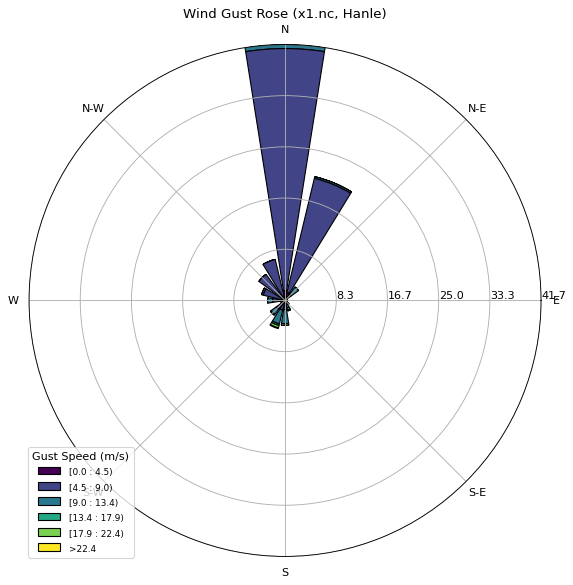

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

#load data
ds = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\x1.nc")

# find wind
if "u10" in ds.variables:
    u = ds["u10"]
    v = ds["v10"]
elif "10m_u_component_of_wind" in ds.variables:
    u = ds["10m_u_component_of_wind"]
    v = ds["10m_v_component_of_wind"]
else:
    raise KeyError("u/v wind components not found.")

# Gust
if "i10fg" in ds.variables:
    gust = ds["i10fg"]
elif "instantaneous_10m_wind_gust" in ds.variables:
    gust = ds["instantaneous_10m_wind_gust"]
else:
    raise KeyError("Wind gust variable not found.")

#lat lon names
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Latitude/longitude not found.")

# hanle location
u = u.sel({lat_name: 32, lon_name: 78}, method="nearest")
v = v.sel({lat_name: 32, lon_name: 78}, method="nearest")
gust = gust.sel({lat_name: 32, lon_name: 78}, method="nearest")

#compute uv direction
direction = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# flatten
gust_vals = gust.values.flatten()
dir_vals = direction.values.flatten()

mask = ~np.isnan(gust_vals)
gust_vals = gust_vals[mask]
dir_vals = dir_vals[mask]

# gust bins
binarray = np.linspace(0, np.max(gust_vals), 6)

#plot wind rose
ax = WindroseAxes.from_ax()

ax.bar(
    dir_vals,
    gust_vals,
    bins=binarray,
    normed=True,   # percent frequency
    edgecolor='black'
)

ax.set_title("Wind Gust Rose (x1.nc, Hanle)")
ax.set_legend(title="Gust Speed (m/s)")
ax.set_rlabel_position(0)

plt.show()

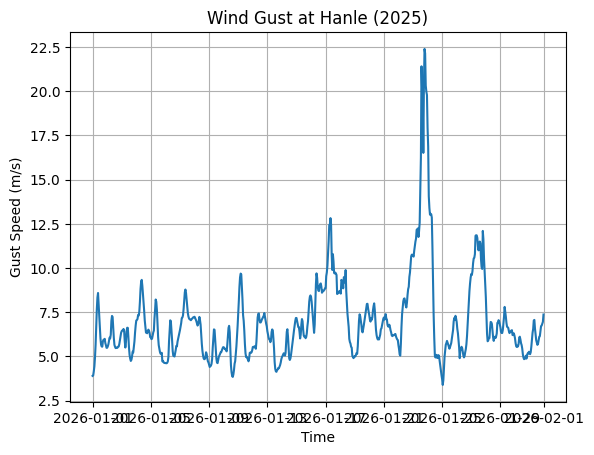

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# data
ds = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\x1.nc")

# gust
if "i10fg" in ds.variables:
    gust = ds["i10fg"]
elif "instantaneous_10m_wind_gust" in ds.variables:
    gust = ds["instantaneous_10m_wind_gust"]
else:
    raise KeyError("Wind gust variable not found. Run print(ds) to check.")

#lat lon
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Latitude/longitude not found.")

#select location
gust = gust.sel({lat_name: 32, lon_name: 78}, method="nearest")

# time
if "time" in ds.coords:
    time = ds["time"]
elif "valid_time" in ds.coords:
    time = ds["valid_time"]
else:
    raise KeyError("Time variable not found.")

# clean
gust_vals = gust.values.flatten()

#plot
plt.figure()

plt.plot(time, gust_vals)

plt.title("Wind Gust at Hanle (2025)")
plt.xlabel("Time")
plt.ylabel("Gust Speed (m/s)")

plt.grid()

plt.show()

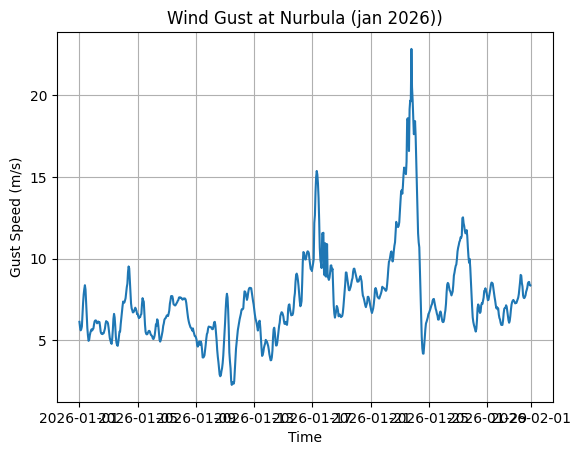

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# data
ds = xr.open_dataset(r"C:\Users\2021n\Downloads\vscodedemo\jan.nc")

# gust
if "i10fg" in ds.variables:
    gust = ds["i10fg"]
elif "instantaneous_10m_wind_gust" in ds.variables:
    gust = ds["instantaneous_10m_wind_gust"]
else:
    raise KeyError("Wind gust variable not found. Run print(ds) to check.")

# lat lon
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Latitude/longitude not found.")

# loc
gust = gust.sel({lat_name: 32, lon_name: 78}, method="nearest")

# time
if "time" in ds.coords:
    time = ds["time"]
elif "valid_time" in ds.coords:
    time = ds["valid_time"]
else:
    raise KeyError("Time variable not found.")

# clean
gust_vals = gust.values.flatten()

#plot
plt.figure()

plt.plot(time, gust_vals)

plt.title("Wind Gust at Nurbula (jan 2026))")
plt.xlabel("Time")
plt.ylabel("Gust Speed (m/s)")

plt.grid()

plt.show()

c:\Users\2021n\Downloads\vscodedemo\pwv\Lib\site-packages\xarray\backends\plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Could not load the ecCodes library!
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


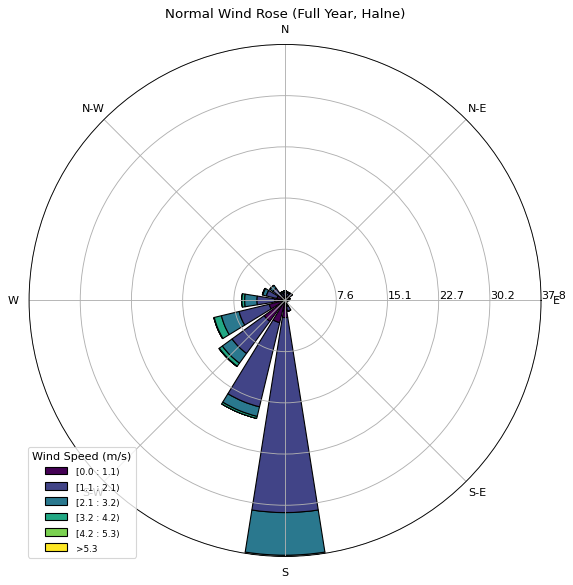

Max wind speed: 5.2815285
Total points: 8760


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# combine
files = [
    r"C:\Users\2021n\Downloads\vscodedemo\JFM.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\A.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\MJJA.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\SOND.nc"
]

ds = xr.open_mfdataset(files, combine="by_coords")

# Ensure chronological order
if "time" in ds.coords:
    ds = ds.sortby("time")
elif "valid_time" in ds.coords:
    ds = ds.sortby("valid_time")

#wind components
if "u10" in ds.variables:
    u = ds["u10"]
    v = ds["v10"]
elif "10m_u_component_of_wind" in ds.variables:
    u = ds["10m_u_component_of_wind"]
    v = ds["10m_v_component_of_wind"]
else:
    raise KeyError("Wind components not found.")

# lat lon
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Lat/Lon not found.")

#location
u = u.sel({lat_name: 32.779, lon_name: 78.964}, method="nearest")
v = v.sel({lat_name: 32.779, lon_name: 78.964}, method="nearest")

# speed and direction
speed = np.sqrt(u**2 + v**2)

direction = (np.degrees(np.arctan2(-u, -v)) + 360) % 360

# clean data
speed_vals = speed.values.flatten()
dir_vals = direction.values.flatten()

mask = ~np.isnan(speed_vals) & ~np.isnan(dir_vals)
speed_vals = speed_vals[mask]
dir_vals = dir_vals[mask]

#bins
binarray = np.linspace(0, np.max(speed_vals), 6)

# wind rose
ax = WindroseAxes.from_ax()

ax.bar(
    dir_vals,
    speed_vals,
    bins=binarray,
    normed=True,
    edgecolor='black'
)

ax.set_title("Normal Wind Rose (Full Year, Halne)")
ax.set_legend(title="Wind Speed (m/s)")
ax.set_rlabel_position(0)

plt.show()

#debug
print("Max wind speed:", np.max(speed_vals))
print("Total points:", len(speed_vals))

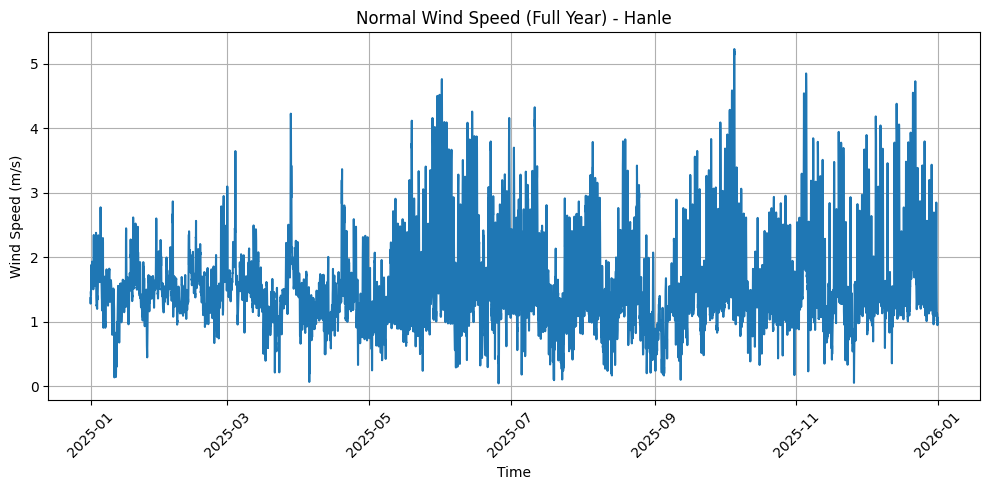

Max normal wind: 5.22819


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

#combine files
files = [
    r"C:\Users\2021n\Downloads\vscodedemo\JFM.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\A.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\MJJA.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\SOND.nc"
]

ds = xr.open_mfdataset(files, combine="by_coords")

# Sort time
if "time" in ds.coords:
    ds = ds.sortby("time")
    time = ds["time"]
elif "valid_time" in ds.coords:
    ds = ds.sortby("valid_time")
    time = ds["valid_time"]
else:
    raise KeyError("Time not found")

# wind components
if "u10" in ds.variables:
    u = ds["u10"]
    v = ds["v10"]
elif "10m_u_component_of_wind" in ds.variables:
    u = ds["10m_u_component_of_wind"]
    v = ds["10m_v_component_of_wind"]
else:
    raise KeyError("Wind components not found")

# location
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
else:
    lat_name = "lat"
    lon_name = "lon"

u = u.sel({lat_name: 32.804, lon_name: 78.396}, method="nearest")
v = v.sel({lat_name: 32.804, lon_name: 78.396}, method="nearest")

# speed
speed = np.sqrt(u**2 + v**2)

speed_vals = speed.values.flatten()

# plot
plt.figure(figsize=(10,5))

plt.plot(time, speed_vals)

plt.title("Normal Wind Speed (Full Year) - Hanle")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")

plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

print("Max normal wind:", np.max(speed_vals))

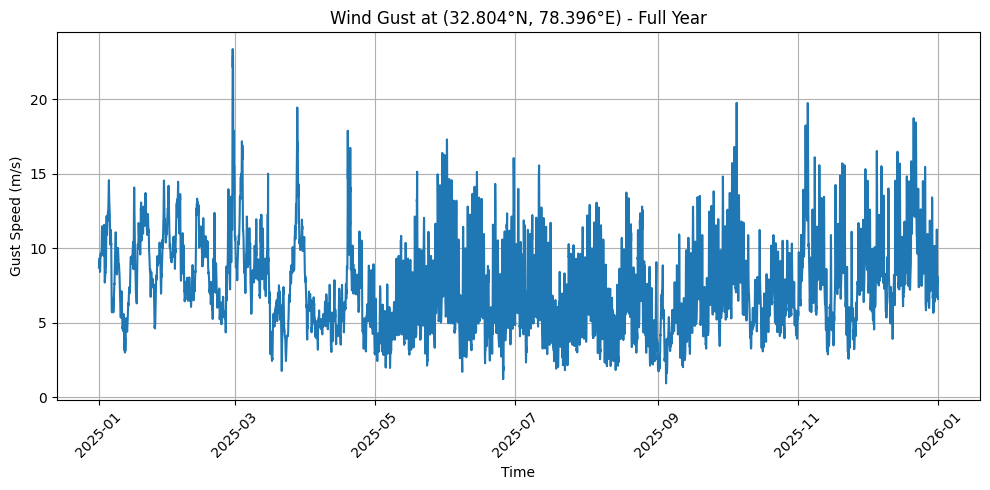

Max gust: 23.360031
Data points: 8760


In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# combine files-
files = [
    r"C:\Users\2021n\Downloads\vscodedemo\JFM.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\A.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\MJJA.nc",
    r"C:\Users\2021n\Downloads\vscodedemo\SOND.nc"
]

ds = xr.open_mfdataset(files, combine="by_coords")

# Ensure chronological order
if "time" in ds.coords:
    ds = ds.sortby("time")
    time = ds["time"]
elif "valid_time" in ds.coords:
    ds = ds.sortby("valid_time")
    time = ds["valid_time"]
else:
    raise KeyError("Time variable not found.")

#gust
if "i10fg" in ds.variables:
    gust = ds["i10fg"]
elif "instantaneous_10m_wind_gust" in ds.variables:
    gust = ds["instantaneous_10m_wind_gust"]
else:
    raise KeyError("Wind gust variable not found.")

#lat lon
if "latitude" in ds.coords:
    lat_name = "latitude"
    lon_name = "longitude"
elif "lat" in ds.coords:
    lat_name = "lat"
    lon_name = "lon"
else:
    raise KeyError("Latitude/longitude not found.")

#location
gust = gust.sel(
    {lat_name: 32.804, lon_name: 78.396},
    method="nearest"
)

#Clean
gust_vals = gust.values.flatten()

#plot
plt.figure(figsize=(10,5))

plt.plot(time, gust_vals)

plt.title("Wind Gust at (32.804°N, 78.396°E) - Full Year")
plt.xlabel("Time")
plt.ylabel("Gust Speed (m/s)")

plt.grid()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Max gust:", np.max(gust_vals))
print("Data points:", len(gust_vals))